In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow import keras
from keras import layers

In [5]:
((X_train, y_train), (X_test, y_test)) = keras.datasets.mnist.load_data()

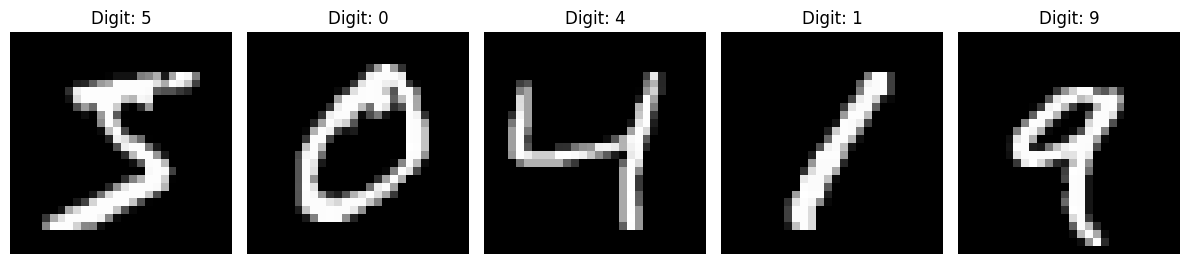

In [8]:
fig, axes = plt.subplots(1, 5, figsize=(12, 3))

for i, (image, image_target) in enumerate(zip(X_train[:5], y_train[:5])):
    image_2d = image.reshape(28, 28)
    axes[i].imshow(image_2d, cmap='gray')
    axes[i].set_title(f"Digit: {image_target}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [9]:
X_train = X_train.reshape((60000, 28, 28, 1)) / 255.0
X_test = X_test.reshape((10000, 28, 28, 1)) / 255.0

In [12]:
model = keras.Sequential([

    layers.Conv2D(32, (3, 3), activation="relu", padding="same", input_shape=(28, 28, 1)), # → (28, 28, 32)
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)), # → (14, 14, 32)
    layers.Dropout(0.25),

    layers.Conv2D(64, (3, 3), activation="relu", padding="same"), # → (14, 14, 64)
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)), # → (7, 7, 64)
    layers.Dropout(0.25),

    layers.Flatten(), # → 3136
    layers.Dense(256, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(10, activation="softmax"),
    
], name="MNIST_CNN")

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "MNIST_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       803,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 872,426 (3.33 MB)

 Trainable params: 871,530 (3.32 MB)

 Non-trainable params: 896 (3.50 KB)

In [13]:
history = model.fit(X_train, y_train, epochs=3, batch_size=64, validation_split=0.1)

Epoch 1/3
844/844 ━━━━━━━━━━━━━━━━━━━━ 64s 72ms/step - accuracy: 0.9526 - loss: 0.1563 - val_accuracy: 0.9838 - val_loss: 0.0555
Epoch 2/3
844/844 ━━━━━━━━━━━━━━━━━━━━ 70s 83ms/step - accuracy: 0.9807 - loss: 0.0627 - val_accuracy: 0.9893 - val_loss: 0.0386
Epoch 3/3
844/844 ━━━━━━━━━━━━━━━━━━━━ 62s 73ms/step - accuracy: 0.9855 - loss: 0.0473 - val_accuracy: 0.9918 - val_loss: 0.0291


In [14]:
def visualize_prediction(x_test, y_true, y_pred, num_samples=10, grid_cols=5):
    
    grid_rows = (num_samples + grid_cols - 1) // grid_cols
    fig, axes = plt.subplots(grid_rows, grid_cols, figsize=(15, 3 * grid_rows))

    if grid_rows == 1:
        axes = axes.reshape(1, -1)

    axes_flat = axes.flatten()

    for i in range(num_samples):
        
        if len(x_test[i].shape) == 1:
            img_size = int(np.sqrt(x_test[i].shape[0]))
            image_2d = x_test[i].reshape(img_size, img_size)
            
        else:
            image_2d = x_test[i]

        axes_flat[i].imshow(image_2d, cmap="gray")

        color = "green" if y_true[i] == y_pred[i] else "red"
        
        axes_flat[i].set_title(
            f"True: {y_true[i]}, Pred: {y_pred[i]}",
            color=color, fontsize=10, fontweight="bold"
        )
        
        axes_flat[i].axis("off")

    for i in range(num_samples, len(axes_flat)):
        axes_flat[i].axis("off")

    plt.tight_layout()
    plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step


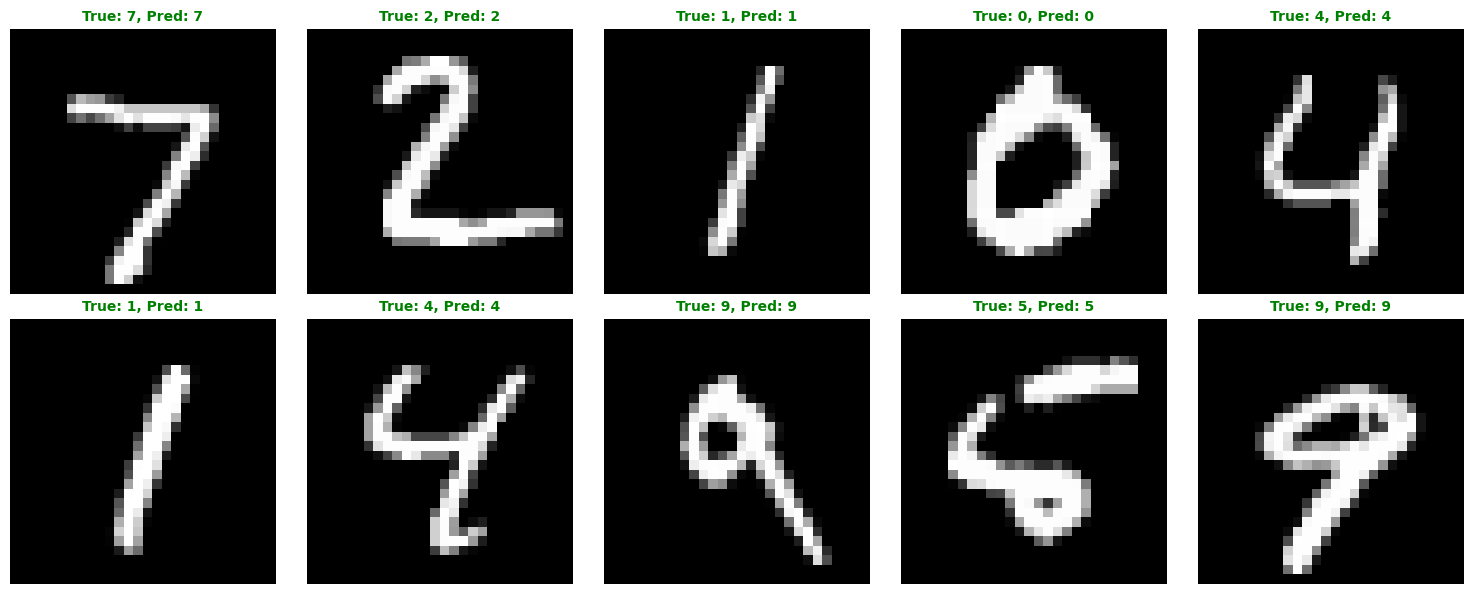

In [15]:
y_pred_probs = model.predict(X_test)
y_pred       = np.argmax(y_pred_probs, axis=1)

visualize_prediction(
    x_test      = X_test.squeeze(),
    y_true      = y_test,
    y_pred      = y_pred,
    num_samples = 10,
    grid_cols   = 5
)